Epoch [50/200], Loss: 4.2865
Epoch [100/200], Loss: 3.5483
Epoch [150/200], Loss: 3.1028
Epoch [200/200], Loss: 2.8340

真实参数: w = 2.5000, b = 3.0000
训练结果: w = 2.6809, b = 1.9229


C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sutut\AppData\Local\Temp\ipykernel_27764\3448001672.py:99: UserWarning: Glyph 26631 (\

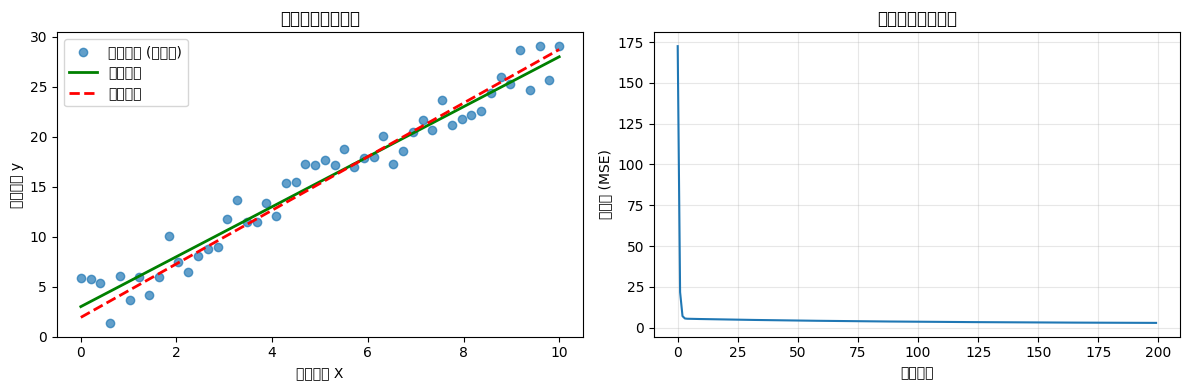

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ========================
# 1. 生成模拟数据（y = wx + b + noise）
# ========================
torch.manual_seed(42)  # 设置随机种子保证结果可复现
num_samples = 50        # 生成50个样本点

# 真实参数值
true_w = 2.5
true_b = 3.0

# 生成输入特征（0~10之间的均匀分布）
X = torch.linspace(0, 10, num_samples).reshape(-1, 1)
# 生成带噪声的标签（y = 2.5x + 3 + 高斯噪声）
y = true_w * X + true_b + torch.randn(X.size()) * 1.5

# ========================
# 2. 定义线性回归模型
# ========================
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # 输入输出维度均为1 (y = wx + b)

    def forward(self, x):
        return self.linear(x)

model = LinearRegression()  # 实例化模型

# ========================
# 3. 设置训练组件
# ========================
criterion = nn.MSELoss()                 # 均方误差损失函数
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器
epochs = 200                            # 训练轮数

# 记录训练过程
loss_history = []

# ========================
# 4. 训练循环
# ========================
for epoch in range(epochs):
    # 前向传播
    predictions = model(X)
    loss = criterion(predictions, y)

    # 反向传播与优化
    optimizer.zero_grad()  # 清空梯度
    loss.backward()        # 计算梯度
    optimizer.step()       # 更新参数

    # 记录损失
    loss_history.append(loss.item())

    # 每50轮打印一次进度
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ========================
# 5. 获取训练结果
# ========================
# 提取学习到的参数
trained_w = model.linear.weight.item()
trained_b = model.linear.bias.item()

print("\n" + "="*50)
print(f"真实参数: w = {true_w:.4f}, b = {true_b:.4f}")
print(f"训练结果: w = {trained_w:.4f}, b = {trained_b:.4f}")
print("="*50)

# ========================
# 6. 结果可视化
# ========================
plt.figure(figsize=(12, 4))

# 子图1：数据与拟合直线
plt.subplot(1, 2, 1)
plt.scatter(X.numpy(), y.numpy(), alpha=0.7, label='原始数据 (含噪声)')
plt.plot(X.numpy(), (true_w * X + true_b).numpy(), 'g-', linewidth=2, label='真实关系')
plt.plot(X.numpy(), model(X).detach().numpy(), 'r--', linewidth=2, label='模型拟合')
plt.xlabel('输入特征 X')
plt.ylabel('输出标签 y')
plt.title('线性回归拟合效果')
plt.legend()

# 子图2：训练损失曲线
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('训练轮数')
plt.ylabel('损失值 (MSE)')
plt.title('训练过程损失变化')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()